# Vollständige Analysestruktur (für die Verteidigung)
Der folgende Block folgt der Logik: EDA -> Statistik -> Kollinearität -> Baseline-ML -> Wichtigkeit -> Schlussfolgerung.

## 1. Laden und erste Prüfung
Ziel: Größe, Datentypen, fehlende Werte und die allgemeine Datenqualität prüfen.

In [ ]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv("dataset_prepared.csv")

print("Form:", raw_df.shape)
display(raw_df.head())
raw_df.info()

print("\nFehlende Werte pro Spalte:")
display(raw_df.isna().sum().sort_values(ascending=False))

numeric_raw = raw_df.select_dtypes(include=["number"]).columns.tolist()
categorical_raw = [c for c in raw_df.columns if c not in numeric_raw]
print("\nNumerische Spalten:", numeric_raw)
print("Kategoriale Spalten:", categorical_raw)

Form: (1000, 15)


,auto_make,auto_model,auto_make_model,auto_year,incident_type,collision_type,incident_severity,number_of_vehicles_involved,bodily_injuries,witnesses,incident_hour_of_the_day,property_damage,authorities_contacted,incident_state,vehicle_claim
0,Saab,92x,Saab 92x,2004,Single Vehicle Collision,Side Collision,Major Damage,1,1,2,5,YES,Police,SC,52080
1,Mercedes,E400,Mercedes E400,2007,Vehicle Theft,?,Minor Damage,1,0,0,8,?,Police,VA,3510
2,Dodge,RAM,Dodge RAM,2007,Multi-vehicle Collision,Rear Collision,Minor Damage,3,2,3,7,NO,Police,NY,23100
3,Chevrolet,Tahoe,Chevrolet Tahoe,2014,Single Vehicle Collision,Front Collision,Major Damage,1,1,2,5,?,Police,OH,50720
4,Accura,RSX,Accura RSX,2009,Vehicle Theft,?,Minor Damage,1,0,1,20,NO,NaN,NY,4550


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   auto_make                    1000 non-null   str  
 1   auto_model                   1000 non-null   str  
 2   auto_make_model              1000 non-null   str  
 3   auto_year                    1000 non-null   int64
 4   incident_type                1000 non-null   str  
 5   collision_type               1000 non-null   str  
 6   incident_severity            1000 non-null   str  
 7   number_of_vehicles_involved  1000 non-null   int64
 8   bodily_injuries              1000 non-null   int64
 9   witnesses                    1000 non-null   int64
 10  incident_hour_of_the_day     1000 non-null   int64
 11  property_damage              1000 non-null   str  
 12  authorities_contacted        909 non-null    str  
 13  incident_state               1000 non-null   str  
 14  vehi

authorities_contacted          91
auto_model                      0
auto_make                       0
auto_year                       0
incident_type                   0
collision_type                  0
auto_make_model                 0
incident_severity               0
number_of_vehicles_involved     0
witnesses                       0
bodily_injuries                 0
incident_hour_of_the_day        0
property_damage                 0
incident_state                  0
vehicle_claim                   0
dtype: int64


Numerische Spalten: ['auto_year', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'incident_hour_of_the_day', 'vehicle_claim']
Kategoriale Spalten: ['auto_make', 'auto_model', 'auto_make_model', 'incident_type', 'collision_type', 'incident_severity', 'property_damage', 'authorities_contacted', 'incident_state']


## 2. Bereinigung und Vorbereitung
Schritte: spezielle Missing-Werte ersetzen, Imputation, Typkonvertierung, Duplikate entfernen.

In [ ]:
df_clean = raw_df.copy()

# Spezielle Kennzeichen für fehlende Werte ersetzen
df_clean = df_clean.replace("?", np.nan)

# Explizite Typ-Trennung: numerisch vs kategorial
num_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Imputation: Median für numerische, Modus für kategoriale Variablen
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    if df_clean[c].isna().any():
        mode_series = df_clean[c].mode(dropna=True)
        if len(mode_series) > 0:
            df_clean[c] = df_clean[c].fillna(mode_series.iloc[0])

# Kategoriale Spalten in category umwandeln
for c in cat_cols:
    df_clean[c] = df_clean[c].astype("category")

print("Duplikate vor dem Entfernen:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Form nach der Bereinigung:", df_clean.shape)
print("Verbleibende fehlende Werte:", int(df_clean.isna().sum().sum()))

display(df_clean.head())

Duplikate vor dem Entfernen: 0
Form nach der Bereinigung: (1000, 15)
Verbleibende fehlende Werte: 0


,auto_make,auto_model,auto_make_model,auto_year,incident_type,collision_type,incident_severity,number_of_vehicles_involved,bodily_injuries,witnesses,incident_hour_of_the_day,property_damage,authorities_contacted,incident_state,vehicle_claim
0,Saab,92x,Saab 92x,2004,Single Vehicle Collision,Side Collision,Major Damage,1,1,2,5,YES,Police,SC,52080
1,Mercedes,E400,Mercedes E400,2007,Vehicle Theft,Rear Collision,Minor Damage,1,0,0,8,NO,Police,VA,3510
2,Dodge,RAM,Dodge RAM,2007,Multi-vehicle Collision,Rear Collision,Minor Damage,3,2,3,7,NO,Police,NY,23100
3,Chevrolet,Tahoe,Chevrolet Tahoe,2014,Single Vehicle Collision,Front Collision,Major Damage,1,1,2,5,NO,Police,OH,50720
4,Accura,RSX,Accura RSX,2009,Vehicle Theft,Rear Collision,Minor Damage,1,0,1,20,NO,Police,NY,4550


## 3. Explorative Datenanalyse (EDA)
Wir betrachten die Zielvariable vehicle_claim, grundlegende Gruppierungen und Korrelationen numerischer Merkmale.

count     1000.000000
mean     37928.950000
std      18886.252893
min         70.000000
25%      30292.500000
50%      42100.000000
75%      50822.500000
max      79560.000000
Name: vehicle_claim, dtype: float64


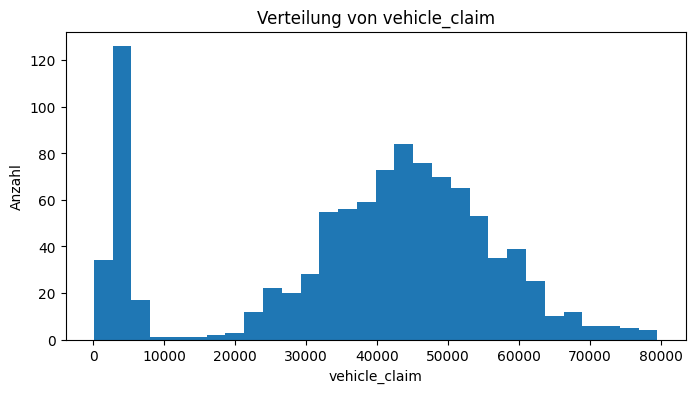

In [ ]:
import matplotlib.pyplot as plt

df_clean["vehicle_claim"] = pd.to_numeric(df_clean["vehicle_claim"], errors="coerce")

print(df_clean["vehicle_claim"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df_clean["vehicle_claim"], bins=30)
plt.title("Verteilung von vehicle_claim")
plt.xlabel("vehicle_claim")
plt.ylabel("Anzahl")
plt.show()

In [ ]:
display(df_clean.groupby("incident_type", observed=False)["vehicle_claim"].mean().sort_values(ascending=False))
display(df_clean.groupby("incident_severity", observed=False)["vehicle_claim"].mean().sort_values(ascending=False))

incident_type
Single Vehicle Collision    46479.900744
Multi-vehicle Collision     44157.374702
Vehicle Theft                3998.510638
Parked Car                   3806.547619
Name: vehicle_claim, dtype: float64

incident_severity
Major Damage      45950.579710
Total Loss        44797.571429
Minor Damage      34895.395480
Trivial Damage     3892.222222
Name: vehicle_claim, dtype: float64

## 4. Hauptstatistik
Kategoriale Merkmale: ANOVA + Eta-Quadrat. Numerische Merkmale: Spearman.

In [55]:
from scipy.stats import f_oneway, spearmanr

df = df_clean
target = "vehicle_claim"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Spearman (numerische Merkmale)
num_rows = []
for c in num_cols:
    part = df[[c, target]].dropna()
    if part[c].nunique() < 2:
        continue

    rho, p = spearmanr(part[c], part[target])

    num_rows.append({
        "feature": c,
        "test": "spearman",
        "effect": rho,
        "p_value": p
    })

# ANOVA + eta²
def anova_eta2(df, col, target):
    part = df[[col, target]].dropna()
    if part[col].nunique() < 2:
        return None

    groups = [g[target].values for _, g in part.groupby(col)]
    f_stat, p_val = f_oneway(*groups)

    grand_mean = part[target].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((part[target] - grand_mean) ** 2).sum()
    eta2 = ss_between / ss_total if ss_total > 0 else None

    return {
        "feature": col,
        "test": "anova",
        "effect": eta2,
        "p_value": p_val
    }

cat_rows = []
for c in cat_cols:
    if c == target:
        continue
    res = anova_eta2(df, c, target)
    if res:
        cat_rows.append(res)

stats_table = pd.DataFrame(num_rows + cat_rows)
stats_table = stats_table.sort_values("effect", ascending=False)

display(stats_table)
display(stats_table[stats_table["p_value"] < 0.05])

,feature,test,effect,p_value
8,incident_type,anova,0.706488,1.599681e-264
10,incident_severity,anova,0.388658,5.839527e-106
12,authorities_contacted,anova,0.237632,2.562536e-58
1,number_of_vehicles_involved,spearman,0.200743,1.499460e-10
9,collision_type,anova,0.200740,3.091114e-49
4,incident_hour_of_the_day,spearman,0.174234,2.933759e-08
2,bodily_injuries,spearman,0.057891,6.726219e-02
6,auto_model,anova,0.038493,4.502535e-01
7,auto_make_model,anova,0.038493,4.502535e-01
13,incident_state,anova,0.011313,7.895258e-02


,feature,test,effect,p_value
8,incident_type,anova,0.706488,1.599681e-264
10,incident_severity,anova,0.388658,5.839527e-106
12,authorities_contacted,anova,0.237632,2.562536e-58
1,number_of_vehicles_involved,spearman,0.200743,1.499460e-10
9,collision_type,anova,0.200740,3.091114e-49
4,incident_hour_of_the_day,spearman,0.174234,2.933759e-08


## 5. Prüfung auf Multikollinearität
Wir betrachten Abhängigkeiten zwischen kategorialen Merkmalen und Korrelationen numerischer Merkmale.

In [ ]:
if "incident_type" in df_clean.columns and "collision_type" in df_clean.columns:
    display(pd.crosstab(df_clean["incident_type"], df_clean["collision_type"]))

display(df_clean.corr(numeric_only=True))

collision_type,Front Collision,Rear Collision,Side Collision
incident_type,,,
Multi-vehicle Collision,115,152,152
Parked Car,0,84,0
Single Vehicle Collision,139,140,124
Vehicle Theft,0,94,0


,auto_year,number_of_vehicles_involved,bodily_injuries,witnesses,incident_hour_of_the_day,vehicle_claim
auto_year,1.000000,0.034554,-0.020527,0.045791,0.021368,-0.042768
number_of_vehicles_involved,0.034554,1.000000,0.014030,-0.014669,0.120794,0.269393
bodily_injuries,-0.020527,0.014030,1.000000,-0.005606,-0.034563,0.043449
witnesses,0.045791,-0.014669,-0.005606,1.000000,0.006527,-0.022564
incident_hour_of_the_day,0.021368,0.120794,-0.034563,0.006527,1.000000,0.215626
vehicle_claim,-0.042768,0.269393,0.043449,-0.022564,0.215626,1.000000


## 6. Schlüsselfall: incident_severity vs vehicle_claim

In [ ]:
display(
    df_clean.groupby("incident_severity", observed=False)["vehicle_claim"].agg(["mean", "median", "count"])
)

groups_case = [
    g["vehicle_claim"].values
    for _, g in df_clean.groupby("incident_severity", observed=False)
]

,mean,median,count
incident_severity,,,
Major Damage,45950.579710,45600.0,276
Minor Damage,34895.395480,40005.0,354
Total Loss,44797.571429,45280.0,280
Trivial Damage,3892.222222,3845.0,90


## 7. Baseline-Modell (Random Forest)
Wir bauen ein einfaches Baseline-Modell, um die prädiktive Wichtigkeit der Merkmale zu prüfen.

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

ml_df = df_clean.copy()

# Erweiterter Leakage-Check: claim-nahe Komponenten entfernen
candidate_leakage = [
    c for c in ml_df.columns
    if ("claim" in c.lower()) and (c != "vehicle_claim")
]
if candidate_leakage:
    print("Entfernte potenzielle Leakage-Spalten:", candidate_leakage)
    ml_df = ml_df.drop(columns=candidate_leakage)

# One-Hot-Kodierung
ml_encoded = pd.get_dummies(ml_df, drop_first=True)

X = ml_encoded.drop("vehicle_claim", axis=1)
y = ml_encoded["vehicle_claim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test)

print("R2 (Holdout):", r2_score(y_test, pred))
print("MAE (Holdout):", mean_absolute_error(y_test, pred))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf_model, X, y, cv=cv, scoring="r2", n_jobs=-1)
print("R2 (5-fold CV):", cv_r2.mean(), "+/-", cv_r2.std())

R2 (Holdout): 0.6909038046716134
MAE (Holdout): 7594.104150428171
R2 (5-fold CV): 0.6892592131228026 +/- 0.02411050165417389


## 8. Feature-Wichtigkeit
Wir vergleichen die Modellwichtigkeiten mit dem Ranking aus den statistischen Tests.

In [ ]:
rf_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

display(rf_importance.head(15).to_frame("rf_importance"))

,rf_importance
incident_type_Vehicle Theft,0.395003
incident_type_Parked Car,0.387477
incident_severity_Trivial Damage,0.055497
auto_year,0.019465
incident_hour_of_the_day,0.019280
witnesses,0.007808
bodily_injuries,0.006145
number_of_vehicles_involved,0.004969
authorities_contacted_Other,0.004682
property_damage_YES,0.004621


## 9. Korrelations-Heatmap (Pflicht)
Diese Visualisierung macht Multikollinearität und Signal-Cluster deutlich sichtbarer als eine reine Tabelle.

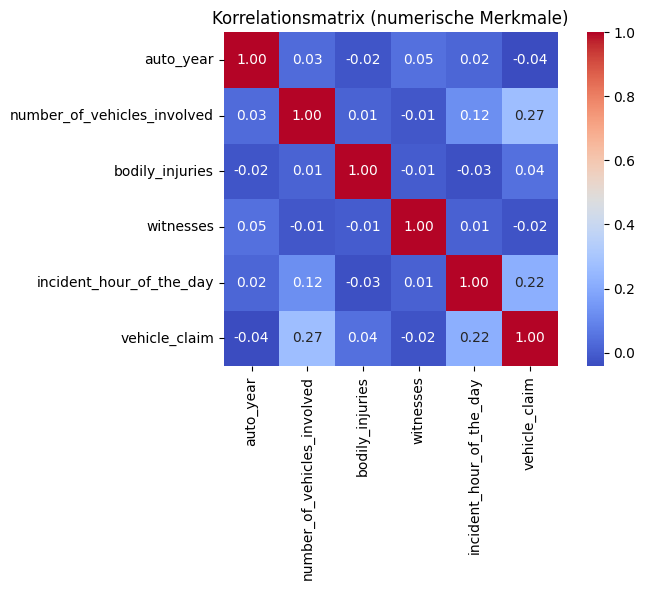

In [60]:
import seaborn as sns

corr_full = df_clean.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korrelationsmatrix (numerische Merkmale)")
plt.tight_layout()
plt.show()

### Strong Final Statement
Die statistische Analyse zeigt, dass insbesondere incident_type und incident_severity den größten Einfluss auf die Höhe der Versicherungszahlung haben. Zusätzlich sind number_of_vehicles_involved, incident_hour_of_the_day und authorities_contacted signifikante Faktoren, während andere Variablen nur schwache oder instabile Zusammenhänge mit der Zielgröße aufweisen.

Der Vergleich zwischen univariater Statistik und Random-Forest-Modell bestätigt die grundlegenden Ergebnisse: Die wichtigsten Merkmale bleiben auch im Vorhersagemodell stabil. Gleichzeitig verlieren einige Variablen im multivariaten Kontext an Bedeutung, was auf überlappende Information und Multikollinearität zwischen den Einflussfaktoren zurückzuführen ist.

Insgesamt lässt sich feststellen, dass die Höhe der Versicherungszahlung hauptsächlich durch Merkmale des Unfallgeschehens bestimmt wird, während Kontextvariablen eine deutlich geringere Rolle spielen.